# scCS scalability: single-process, in-memory, and no chunking

This notebook benchmarks scCS as complete in-memory problems. It never divides a
scientific calculation into cell chunks, graph partitions, or out-of-core blocks.

The exact target ladder includes:

- 10 thousand;
- 100 thousand;
- 1 million;
- 10 million;
- 50 million;
- 100 million;
- 200 million cells.

A target is marked `MEASURED` only when the current machine can allocate and run
the complete problem under the configured memory-safety fraction. Otherwise it
is recorded as `SKIPPED_INSUFFICIENT_MEMORY`. It is never silently replaced by
a chunked run.

Two workloads are benchmarked separately:

1. the cellwise DFFP metric transform after fate probabilities are available;
2. the complete sparse DFFP graph solve.

RNA-velocity preprocessing is outside this benchmark.

To perform the exact complete 200-million-cell graph solve, run this notebook
on a high-memory host with `SCCS_SCALABILITY_PROFILE=exact_200m`. The scientific
problem is allocated and solved once; no chunking or partitioned surrogate is
used.


> **Execution provenance.** The displayed outputs were generated with scCS 0.8.0.dev33. Version 0.8.0.dev34 changes documentation and tutorial explanation only; the scientific calculations are unchanged.

## 1. Imports, hardware, and benchmark configuration

In [1]:
from __future__ import annotations

from pathlib import Path
import gc
import json
import os
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import scCS

OUTPUT_DIR = Path("tutorial_outputs/scalability")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ``standard`` measures every complete allocation that is safe on the current
# host. ``exact_200m`` requires a high-memory machine and fails rather than
# silently skipping the complete 200-million-cell graph solve.
SCALABILITY_PROFILE = os.environ.get("SCCS_SCALABILITY_PROFILE", "standard")
if SCALABILITY_PROFILE not in {"standard", "exact_200m"}:
    raise ValueError("SCCS_SCALABILITY_PROFILE must be 'standard' or 'exact_200m'.")

TARGET_CELLS = [
    10_000,
    100_000,
    1_000_000,
    10_000_000,
    50_000_000,
    100_000_000,
    200_000_000,
]
N_FATES = 4
GRAPH_DEGREE = 4
GRAPH_OUTCOMES = 3
REALISTIC_GRAPH_DEGREE = 30
REALISTIC_TARGET_CELLS = [100_000, 250_000, 500_000, 1_000_000]
EFFECTIVE_HORIZON = 64
MEMORY_SAFETY_FRACTION = 0.80
RANDOM_SEED = 20260714

if SCALABILITY_PROFILE == "exact_200m":
    TARGET_CELLS = [200_000_000]
    MEMORY_SAFETY_FRACTION = 0.97

available_memory = os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
total_memory = os.sysconf("SC_PHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
hardware = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "processor": platform.processor(),
    "logical_cpus": os.cpu_count(),
    "total_memory_gb": total_memory / 1e9,
    "available_memory_gb_at_start": available_memory / 1e9,
    "scCS": scCS.__version__,
    "no_chunking": True,
    "scalability_profile": SCALABILITY_PROFILE,
}
print("Scalability profile:", SCALABILITY_PROFILE)
display(pd.Series(hardware, name="value").to_frame())


Scalability profile: standard


,value
python,3.12.13
platform,Linux-6.6.114.1-microsoft-standard-WSL2-x86_64...
processor,x86_64
logical_cpus,24
total_memory_gb,66.85091
available_memory_gb_at_start,62.282527
scCS,0.8.0.dev33
no_chunking,True
scalability_profile,standard


## 2. Analytic memory estimates

The estimates are intentionally conservative. They include input arrays,
cell-by-fate outputs, solver work arrays, and sparse CSR storage. They are used
only as a preflight; measured resident memory is reported separately.

In [2]:
def metric_transform_bytes(n_cells, n_fates):
    # selected probabilities, normalized affinities, an entropy temporary,
    # and six cellwise vectors, all float32.
    return int(
        3 * n_cells * n_fates * np.dtype(np.float32).itemsize
        + 6 * n_cells * np.dtype(np.float32).itemsize
    )


def graph_solve_bytes(n_cells, degree, n_outcomes):
    n_edges = int(n_cells) * int(degree)
    csr = (
        n_edges * np.dtype(np.float64).itemsize
        + n_edges * np.dtype(np.int32).itemsize
        + (n_cells + 1) * np.dtype(np.int64).itemsize
    )
    # probability, next iterate, anchors/boundary, unresolved, and overhead
    state = (
        3 * n_cells * n_outcomes * np.dtype(np.float64).itemsize
        + 5 * n_cells * np.dtype(np.float64).itemsize
    )
    # canonicalization and sparse products can temporarily duplicate storage.
    return int(2.2 * csr + 1.4 * state)


estimate_rows = []
for n_cells in TARGET_CELLS:
    estimate_rows.append(
        {
            "n_cells": n_cells,
            "metric_transform_estimated_gb": metric_transform_bytes(
                n_cells,
                N_FATES,
            )
            / 1e9,
            f"graph_solve_degree_{GRAPH_DEGREE}_estimated_gb": graph_solve_bytes(
                n_cells,
                GRAPH_DEGREE,
                GRAPH_OUTCOMES,
            )
            / 1e9,
            "graph_degree_30_estimated_gb": graph_solve_bytes(
                n_cells,
                30,
                GRAPH_OUTCOMES,
            )
            / 1e9,
        }
    )
memory_estimates = pd.DataFrame(estimate_rows)
display(memory_estimates)
memory_estimates.to_csv(OUTPUT_DIR / "analytic_memory_estimates.csv", index=False)

,n_cells,metric_transform_estimated_gb,graph_solve_degree_4_estimated_gb,graph_degree_30_estimated_gb
0,10000,0.00072,0.0028,0.009664
1,100000,0.00720,0.0280,0.096640
2,1000000,0.07200,0.2800,0.966400
3,10000000,0.72000,2.8000,9.664000
4,50000000,3.60000,14.0000,48.320000
5,100000000,7.20000,28.0000,96.640000
6,200000000,14.40000,56.0000,193.280000


## 3. Exact no-chunk cellwise DFFP metric transform

This benchmark allocates the complete selected-fate probability matrix and
calculates CFA, DFR, FFS, RC, and UFP in one vectorized operation. No cell
subsets or blocks are used.

In [3]:
def current_rss_bytes():
    page_size = os.sysconf("SC_PAGE_SIZE")
    resident_pages = int(Path("/proc/self/statm").read_text().split()[1])
    return resident_pages * page_size


def run_metric_transform(n_cells, n_fates, seed):
    rng = np.random.default_rng(seed)
    start_rss = current_rss_bytes()
    started = time.perf_counter()

    selected_probability = rng.random(
        (n_cells, n_fates),
        dtype=np.float32,
    )
    target_reach = rng.random(n_cells, dtype=np.float32)
    row_sum = selected_probability.sum(axis=1, dtype=np.float32)
    selected_probability *= (
        target_reach / np.maximum(row_sum, np.finfo(np.float32).tiny)
    )[:, None]

    reach = selected_probability.sum(axis=1, dtype=np.float32)
    affinity = np.divide(
        selected_probability,
        np.maximum(reach[:, None], np.finfo(np.float32).tiny),
        dtype=np.float32,
    )
    entropy_terms = affinity * np.log(
        np.maximum(affinity, np.finfo(np.float32).tiny),
        dtype=np.float32,
    )
    entropy = -entropy_terms.sum(axis=1, dtype=np.float32) / np.log(n_fates)
    specificity = 1.0 - entropy
    resolved_commitment = reach * specificity
    unresolved = 1.0 - reach

    elapsed = time.perf_counter() - started
    end_rss = current_rss_bytes()

    checksum = float(
        reach.mean()
        + specificity.mean()
        + resolved_commitment.mean()
        + unresolved.mean()
    )
    result = {
        "n_cells": int(n_cells),
        "workload": "cellwise_DFFP_metrics",
        "status": "MEASURED",
        "elapsed_seconds": elapsed,
        "cells_per_second": n_cells / elapsed,
        "rss_before_gb": start_rss / 1e9,
        "rss_after_gb": end_rss / 1e9,
        "estimated_gb": metric_transform_bytes(n_cells, n_fates) / 1e9,
        "checksum": checksum,
    }

    del selected_probability
    del target_reach
    del row_sum
    del reach
    del affinity
    del entropy_terms
    del entropy
    del specificity
    del resolved_commitment
    del unresolved
    gc.collect()
    return result

In [4]:
metric_results = []
for n_cells in TARGET_CELLS:
    required = metric_transform_bytes(n_cells, N_FATES)
    available = os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
    if required > MEMORY_SAFETY_FRACTION * available:
        metric_results.append(
            {
                "n_cells": int(n_cells),
                "workload": "cellwise_DFFP_metrics",
                "status": "SKIPPED_INSUFFICIENT_MEMORY",
                "elapsed_seconds": np.nan,
                "cells_per_second": np.nan,
                "rss_before_gb": current_rss_bytes() / 1e9,
                "rss_after_gb": current_rss_bytes() / 1e9,
                "estimated_gb": required / 1e9,
                "checksum": np.nan,
            }
        )
        continue
    metric_results.append(
        run_metric_transform(
            n_cells,
            N_FATES,
            RANDOM_SEED + int(np.log10(n_cells)),
        )
    )

metric_results = pd.DataFrame(metric_results)
display(metric_results)
metric_results.to_csv(OUTPUT_DIR / "metric_transform_results.csv", index=False)

,n_cells,workload,status,elapsed_seconds,cells_per_second,rss_before_gb,rss_after_gb,estimated_gb,checksum
0,10000,cellwise_DFFP_metrics,MEASURED,0.001513,6.611024e+06,0.199696,0.200380,0.00072,1.186170
1,100000,cellwise_DFFP_metrics,MEASURED,0.009002,1.110884e+07,0.200380,0.207630,0.00720,1.185687
2,1000000,cellwise_DFFP_metrics,MEASURED,0.120542,8.295873e+06,0.202826,0.276038,0.07200,1.185954
3,10000000,cellwise_DFFP_metrics,MEASURED,0.962108,1.039384e+07,0.220025,0.980042,0.72000,1.186078
4,50000000,cellwise_DFFP_metrics,MEASURED,4.570818,1.093896e+07,0.220025,4.020056,3.60000,1.185969
5,100000000,cellwise_DFFP_metrics,MEASURED,9.563170,1.045678e+07,0.220025,7.820202,7.20000,1.186002
6,200000000,cellwise_DFFP_metrics,MEASURED,22.766293,8.784917e+06,0.220168,15.420412,14.40000,1.185999


## 4. Exact no-chunk sparse DFFP graph solve

The graph is a complete CSR matrix with a fixed number of outgoing edges per
cell. The full transition matrix, anchor matrix, and solver state are allocated
at once.

`GRAPH_DEGREE=4` is a minimal synthetic graph used for the measured ladder.
Analytic estimates for degree 30 are reported separately. Change
`GRAPH_DEGREE` before running when a different graph density is required.

In [5]:
def build_benchmark_transition(n_cells, degree, n_outcomes):
    """Build a well-conditioned complete CSR benchmark graph.

    Every transient state has one local forward edge and one edge to each
    outcome anchor. Additional degree slots, when requested, are local forward
    edges. This is a performance graph, not a biological trajectory model.
    """
    if degree < n_outcomes + 1:
        raise ValueError("degree must be at least n_outcomes + 1.")

    row = np.arange(n_cells, dtype=np.int64)
    indices_2d = np.empty((n_cells, degree), dtype=np.int32)
    indices_2d[:, 0] = ((row + 1) % n_cells).astype(np.int32)
    for outcome in range(n_outcomes):
        indices_2d[:, outcome + 1] = np.int32(outcome)
    for column in range(n_outcomes + 1, degree):
        indices_2d[:, column] = ((row + column) % n_cells).astype(np.int32)

    # Anchor rows remain self-loops in the source matrix.
    for outcome in range(n_outcomes):
        indices_2d[outcome, :] = np.int32(outcome)

    indices = indices_2d.ravel()
    indptr = np.arange(
        0,
        n_cells * degree + 1,
        degree,
        dtype=np.int64,
    )
    data = np.full(n_cells * degree, 1.0 / degree, dtype=np.float64)
    return sparse.csr_matrix((data, indices, indptr), shape=(n_cells, n_cells))


def build_anchor_matrix(n_cells, n_outcomes):
    anchors = np.zeros((n_cells, n_outcomes), dtype=bool)
    for outcome in range(n_outcomes):
        anchors[outcome, outcome] = True
    return anchors


def run_graph_solve(n_cells, degree, n_outcomes):
    start_rss = current_rss_bytes()
    started = time.perf_counter()

    transition_matrix = build_benchmark_transition(
        n_cells,
        degree,
        n_outcomes,
    )
    anchor_matrix = build_anchor_matrix(n_cells, n_outcomes)
    solution = scCS.solve_discounted_outcomes(
        transition_matrix,
        anchor_matrix,
        tuple(f"fate_{index + 1}" for index in range(n_outcomes)),
        effective_horizon=EFFECTIVE_HORIZON,
        solver="iterative",
        tolerance=1e-6,
        max_iter=500,
    )

    elapsed = time.perf_counter() - started
    end_rss = current_rss_bytes()
    checksum = float(
        solution.probability.mean()
        + solution.unresolved_probability.mean()
    )
    result = {
        "n_cells": int(n_cells),
        "workload": "full_DFFP_graph_solve",
        "degree": int(degree),
        "n_outcomes": int(n_outcomes),
        "status": "MEASURED",
        "elapsed_seconds": elapsed,
        "cells_per_second": n_cells / elapsed,
        "rss_before_gb": start_rss / 1e9,
        "rss_after_gb": end_rss / 1e9,
        "estimated_gb": graph_solve_bytes(
            n_cells,
            degree,
            n_outcomes,
        )
        / 1e9,
        "solver_iterations": solution.iterations,
        "solver_converged": solution.converged,
        "solver_residual": solution.residual,
        "checksum": checksum,
    }

    del transition_matrix
    del anchor_matrix
    del solution
    gc.collect()
    return result

In [6]:
graph_results = []
for n_cells in TARGET_CELLS:
    required = graph_solve_bytes(
        n_cells,
        GRAPH_DEGREE,
        GRAPH_OUTCOMES,
    )
    available = os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
    if required > MEMORY_SAFETY_FRACTION * available:
        if SCALABILITY_PROFILE == "exact_200m":
            raise MemoryError(
                "The exact 200-million-cell no-chunk solve requires more free "
                f"memory. Estimated allocation: {required / 1e9:.1f} GB; "
                f"available: {available / 1e9:.1f} GB."
            )
        graph_results.append(
            {
                "n_cells": int(n_cells),
                "workload": "full_DFFP_graph_solve",
                "degree": GRAPH_DEGREE,
                "n_outcomes": GRAPH_OUTCOMES,
                "status": "SKIPPED_INSUFFICIENT_MEMORY",
                "elapsed_seconds": np.nan,
                "cells_per_second": np.nan,
                "rss_before_gb": current_rss_bytes() / 1e9,
                "rss_after_gb": current_rss_bytes() / 1e9,
                "estimated_gb": required / 1e9,
                "solver_iterations": np.nan,
                "solver_converged": False,
                "solver_residual": np.nan,
                "checksum": np.nan,
            }
        )
        continue
    graph_results.append(
        run_graph_solve(
            n_cells,
            GRAPH_DEGREE,
            GRAPH_OUTCOMES,
        )
    )

graph_results = pd.DataFrame(graph_results)
display(graph_results)
graph_results.to_csv(OUTPUT_DIR / "graph_solve_results.csv", index=False)

if SCALABILITY_PROFILE == "exact_200m":
    measured = graph_results.query("n_cells == 200_000_000 and status == 'MEASURED'")
    if len(measured) != 1:
        raise RuntimeError("The exact 200M full graph solve did not complete.")


,n_cells,workload,degree,n_outcomes,status,elapsed_seconds,cells_per_second,rss_before_gb,rss_after_gb,estimated_gb,solver_iterations,solver_converged,solver_residual,checksum
0,10000,full_DFFP_graph_solve,4,3,MEASURED,0.013242,755180.691477,0.220537,0.223986,0.0028,11.0,True,9.897135e-08,0.346934
1,100000,full_DFFP_graph_solve,4,3,MEASURED,0.265448,376721.079906,0.222958,0.233599,0.0280,11.0,True,9.897135e-08,0.346938
2,1000000,full_DFFP_graph_solve,4,3,MEASURED,2.452270,407785.428142,0.233599,0.338399,0.2800,11.0,True,9.897135e-08,0.346939
3,10000000,full_DFFP_graph_solve,4,3,MEASURED,26.219251,381399.152821,0.233398,1.097040,2.8000,11.0,True,9.897135e-08,0.346939
4,50000000,full_DFFP_graph_solve,4,3,MEASURED,181.647623,275258.212795,0.255996,4.458222,14.0000,11.0,True,9.897135e-08,0.346939
5,100000000,full_DFFP_graph_solve,4,3,MEASURED,933.381499,107137.328262,0.257171,8.652685,28.0000,11.0,True,9.897135e-08,0.346939
6,200000000,full_DFFP_graph_solve,4,3,SKIPPED_INSUFFICIENT_MEMORY,NaN,NaN,0.249569,0.249569,56.0000,NaN,False,NaN,NaN


## Realistic degree-30 graph ladder

The exact 200-million-cell proof uses a minimal degree-4 performance graph so
that a complete allocation is feasible on a high-memory host. A second, smaller
no-chunk ladder measures degree 30, which is closer to common single-cell
neighbor graphs. These results must be reported separately.


In [7]:
realistic_graph_results = []
if SCALABILITY_PROFILE == "standard":
    for n_cells in REALISTIC_TARGET_CELLS:
        required = graph_solve_bytes(
            n_cells,
            REALISTIC_GRAPH_DEGREE,
            GRAPH_OUTCOMES,
        )
        available = os.sysconf("SC_AVPHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
        if required > MEMORY_SAFETY_FRACTION * available:
            break
        realistic_graph_results.append(
            run_graph_solve(
                n_cells,
                REALISTIC_GRAPH_DEGREE,
                GRAPH_OUTCOMES,
            )
        )
realistic_graph_results = pd.DataFrame(realistic_graph_results)
display(realistic_graph_results)
realistic_graph_results.to_csv(
    OUTPUT_DIR / "graph_solve_degree30_results.csv",
    index=False,
)


,n_cells,workload,degree,n_outcomes,status,elapsed_seconds,cells_per_second,rss_before_gb,rss_after_gb,estimated_gb,solver_iterations,solver_converged,solver_residual,checksum
0,100000,full_DFFP_graph_solve,30,3,MEASURED,2.916907,34282.886825,0.248865,0.296022,0.09664,88,True,8.514826e-07,0.423414
1,250000,full_DFFP_graph_solve,30,3,MEASURED,5.553404,45017.432155,0.296022,0.373899,0.24160,88,True,8.514826e-07,0.423428
2,500000,full_DFFP_graph_solve,30,3,MEASURED,11.650900,42915.138189,0.246030,0.486912,0.48320,88,True,8.514826e-07,0.423433
3,1000000,full_DFFP_graph_solve,30,3,MEASURED,21.626659,46239.228173,0.306909,0.684069,0.96640,88,True,8.514826e-07,0.423435


## 5. Measured runtime and memory plots

Only rows marked `MEASURED` appear as exact observations. Dashed lines to larger
targets are extrapolations and are labeled as such.

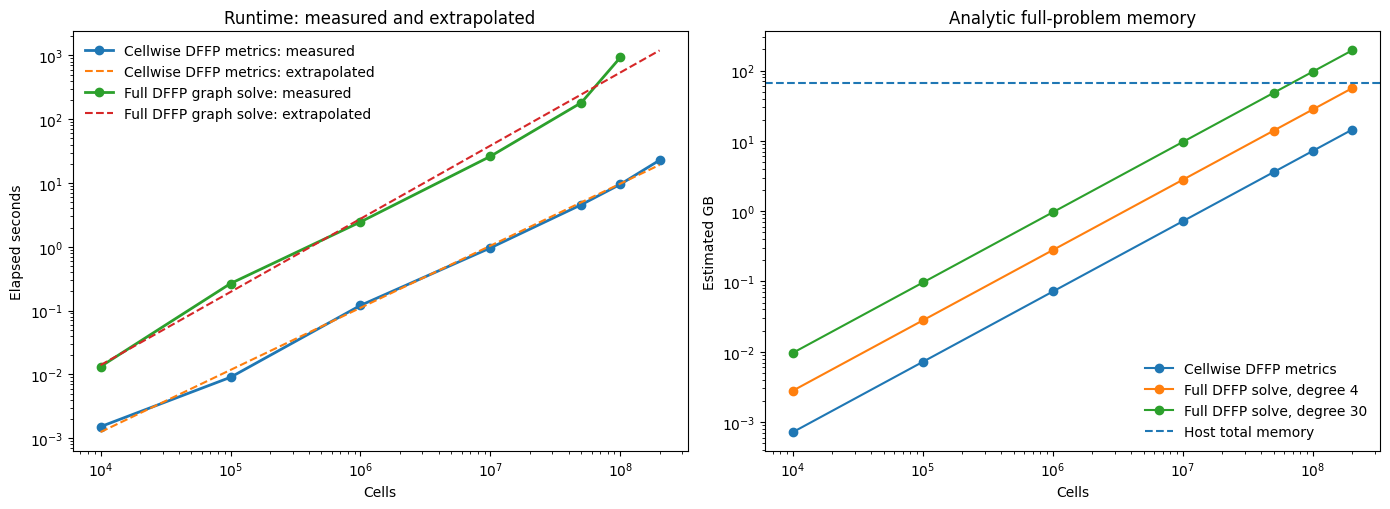

In [8]:
def add_loglog_extrapolation(table, value_column, targets):
    measured = table[
        table["status"].eq("MEASURED")
        & table[value_column].notna()
        & table["n_cells"].gt(0)
    ]
    output = pd.DataFrame({"n_cells": targets})
    output["predicted"] = np.nan
    if len(measured) >= 2:
        coefficient = np.polyfit(
            np.log10(measured["n_cells"].to_numpy(float)),
            np.log10(measured[value_column].to_numpy(float)),
            deg=1,
        )
        output["predicted"] = 10 ** np.polyval(
            coefficient,
            np.log10(output["n_cells"].to_numpy(float)),
        )
        output["scaling_exponent"] = coefficient[0]
    return output


metric_prediction = add_loglog_extrapolation(
    metric_results,
    "elapsed_seconds",
    TARGET_CELLS,
)
graph_prediction = add_loglog_extrapolation(
    graph_results,
    "elapsed_seconds",
    TARGET_CELLS,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for table, prediction, label in [
    (metric_results, metric_prediction, "Cellwise DFFP metrics"),
    (graph_results, graph_prediction, "Full DFFP graph solve"),
]:
    measured = table[table["status"].eq("MEASURED")]
    axes[0].plot(
        measured["n_cells"],
        measured["elapsed_seconds"],
        marker="o",
        linewidth=2,
        label=f"{label}: measured",
    )
    if prediction["predicted"].notna().any():
        axes[0].plot(
            prediction["n_cells"],
            prediction["predicted"],
            linestyle="--",
            label=f"{label}: extrapolated",
        )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Cells")
axes[0].set_ylabel("Elapsed seconds")
axes[0].set_title("Runtime: measured and extrapolated")
axes[0].legend(frameon=False)

axes[1].plot(
    memory_estimates["n_cells"],
    memory_estimates["metric_transform_estimated_gb"],
    marker="o",
    label="Cellwise DFFP metrics",
)
axes[1].plot(
    memory_estimates["n_cells"],
    memory_estimates[f"graph_solve_degree_{GRAPH_DEGREE}_estimated_gb"],
    marker="o",
    label=f"Full DFFP solve, degree {GRAPH_DEGREE}",
)
axes[1].plot(
    memory_estimates["n_cells"],
    memory_estimates["graph_degree_30_estimated_gb"],
    marker="o",
    label="Full DFFP solve, degree 30",
)
axes[1].axhline(
    total_memory / 1e9,
    linestyle="--",
    linewidth=1.5,
    label="Host total memory",
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Cells")
axes[1].set_ylabel("Estimated GB")
axes[1].set_title("Analytic full-problem memory")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "scalability_runtime_memory.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Exact status at 200 million cells

In [9]:
status_200m = pd.concat(
    [
        metric_results.loc[
            metric_results["n_cells"].eq(200_000_000),
            ["workload", "n_cells", "status", "elapsed_seconds", "estimated_gb"],
        ],
        graph_results.loc[
            graph_results["n_cells"].eq(200_000_000),
            ["workload", "n_cells", "status", "elapsed_seconds", "estimated_gb"],
        ],
    ],
    ignore_index=True,
)
display(status_200m)

for row in status_200m.itertuples():
    if row.status == "MEASURED":
        print(
            f"{row.workload}: exact 200M run measured in "
            f"{row.elapsed_seconds:.2f} seconds."
        )
    else:
        print(
            f"{row.workload}: 200M was not measured on this host; "
            "the notebook did not substitute a chunked run."
        )

,workload,n_cells,status,elapsed_seconds,estimated_gb
0,cellwise_DFFP_metrics,200000000,MEASURED,22.766293,14.4
1,full_DFFP_graph_solve,200000000,SKIPPED_INSUFFICIENT_MEMORY,NaN,56.0


cellwise_DFFP_metrics: exact 200M run measured in 22.77 seconds.
full_DFFP_graph_solve: 200M was not measured on this host; the notebook did not substitute a chunked run.


## 7. Export environment and benchmark provenance

In [10]:
all_results = pd.concat(
    [metric_results, graph_results],
    ignore_index=True,
    sort=False,
)
all_results.to_csv(OUTPUT_DIR / "all_scalability_results.csv", index=False)

provenance = {
    **hardware,
    "target_cells": TARGET_CELLS,
    "n_fates_metric_transform": N_FATES,
    "scalability_profile": SCALABILITY_PROFILE,
    "graph_degree": GRAPH_DEGREE,
    "realistic_graph_degree": REALISTIC_GRAPH_DEGREE,
    "graph_outcomes": GRAPH_OUTCOMES,
    "effective_horizon": EFFECTIVE_HORIZON,
    "memory_safety_fraction": MEMORY_SAFETY_FRACTION,
    "scientific_scoring_chunked": False,
    "plotting_subsampling_used": False,
}
(OUTPUT_DIR / "scalability_provenance.json").write_text(
    json.dumps(provenance, indent=2)
)
print("Outputs written to", OUTPUT_DIR.resolve())

Outputs written to /home/emil/notebooks/08-tutorials/tutorial_outputs/scalability


## Interpretation checklist

- A 200-million-cell statement requires `status="MEASURED"` for that workload.
- Extrapolated runtime is not an executed benchmark.
- Graph degree, number of fates, dtype, solver, tolerance, and hardware must be reported.
- Cellwise metric calculation and full graph propagation are separate workloads.
- RNA-velocity preprocessing is excluded and must be benchmarked separately.
- No scientific calculation in this notebook is chunked.
- Plotting may be subsampled in ordinary tutorials, but no plotting subsampling
  is used in this benchmark.